<a href="https://www.kaggle.com/code/afifa242/workload-and-mental-health-in-university-students?scriptVersionId=328385292" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 📊 CSE303 Term Project

## Modeling the Relationship Between Workload and Mental Health in University Students

**Student:** Afifa Tabassum  
**ID:** 2023-1-60-242  
**Course:** CSE303 – Statistics for Data Science

### 📖 Project Overview
This project investigates the relationship between university students' workload and their mental health using survey-based data. The analysis includes data preprocessing, exploratory data analysis (EDA), descriptive statistics, and the implementation of multiple linear regression models from scratch to examine how workload-related factors influence stress, anxiety, sleep hours, and sleep quality.

### 🎯 Objectives
- Analyze workload and mental health survey data.
- Perform descriptive statistical analysis and visualization.
- Explore correlations between workload and mental health indicators.
- Implement linear regression models without using built-in regression functions.
- Interpret results and provide recommendations for student well-being.

### 📂 Dataset
**Kaggle Dataset Path:** `/kaggle/input/datasets/afifa242/cleaned-data`

# Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and Preview Dataset

In [4]:
file_path = r'/kaggle/input/datasets/afifa242/cleaned-data/University Student Workload and Mental Health Survey (Responses) - Form Responses 1.csv'
df = pd.read_csv(file_path)

extracurricular_hours_col = 'If yes, how many hours per week do you spend on extracurricular activities?  (Leave it blank if you do not participate)'
part_time_hours_col = 'If yes, how many hours per week? \n(Leave it blank if you do not participate)'
cgpa_col = 'CGPA (Optional):'
credits_col = 'How many credits are you currently enrolled in?'
extracurricular_col = 'Do you participate in extracurricular activities?  (Clubbing, Volunteering, etc.)'
part_time_job_col = 'Do you have a part-time job? '

df[extracurricular_hours_col] = df[extracurricular_hours_col].fillna(0)
df[part_time_hours_col] = df[part_time_hours_col].fillna(0)

cgpa_median = df[cgpa_col].median()
df[cgpa_col] = df[cgpa_col].fillna(cgpa_median)

credits_median = df[credits_col].median()
df[credits_col] = df[credits_col].fillna(credits_median)

df['Year of Study:'] = df['Year of Study:'].str.extract('(\d+)').astype(int)
df['Gender:'] = df['Gender:'].map({'Male': 1, 'Female': 0})
df[extracurricular_col] = df[extracurricular_col].map({'Yes': 1, 'No': 0})
df[part_time_job_col] = df[part_time_job_col].map({'Yes': 1, 'No': 0})

df = df.drop(columns=['Email Address', 'Timestamp'])


print("\n--- First 5 Rows ---")
print(df.head())

cleaned_file_path = r'/kaggle/input/datasets/afifa242/cleaned-data/cleaned_student_survey.csv'
df.to_csv(cleaned_file_path, index=False)
print(f"\nSuccessfully cleaned the data and saved it to '{cleaned_file_path}'")


--- First 5 Rows ---
   Year of Study:  Gender:  Age:  CGPA (Optional):  \
0               3        1    24              4.00   
1               1        1    20              3.68   
2               3        1    23              3.95   
3               1        0    20              3.68   
4               4        0    24              3.81   

   How many hours do you spend on studying per week?  \
0                                                  6   
1                                                 28   
2                                                 10   
3                                                  2   
4                                                  2   

   How many credits are you currently enrolled in?  \
0                                             12.0   
1                                             12.0   
2                                             20.0   
3                                              9.0   
4                                             

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_58/4195877931.py:20: SyntaxWarning: invalid escape sequence '\d'
  df['Year of Study:'] = df['Year of Study:'].str.extract('(\d+)').astype(int)


OSError: [Errno 30] Read-only file system: '/kaggle/input/datasets/afifa242/cleaned-data/cleaned_student_survey.csv'

# Data Cleaning and Preprocessing

In [5]:
df = pd.read_csv(cleaned_file_path)
print(df.shape)
df.head()

(60, 14)


,Year of Study:,Gender:,Age:,CGPA (Optional):,How many hours do you spend on studying per week?,How many credits are you currently enrolled in?,"Do you participate in extracurricular activities? (Clubbing, Volunteering, etc.)","If yes, how many hours per week do you spend on extracurricular activities? (Leave it blank if you do not participate)",Do you have a part-time job?,"If yes, how many hours per week? \n(Leave it blank if you do not participate)","On a scale of 1-5, how would you rate your stress level this semester?","On a scale of 1-5, how would you rate your anxiety level?","On average, how many hours of sleep do you get per night?","On a scale of 1-10, how would you rate your overall sleep quality?"
0,3,1,24,4.00,6,12.0,0,0.0,1,30.0,3,2,4.0,4
1,1,1,20,3.68,28,12.0,0,0.0,0,0.0,5,5,2.0,1
2,3,1,23,3.95,10,20.0,1,1.0,0,0.0,3,3,4.0,2
3,1,0,20,3.68,2,9.0,0,0.0,1,10.0,4,4,4.0,4
4,4,0,24,3.81,2,12.0,1,1.0,1,8.0,5,5,4.0,2


# Exploratory Data Analysis (EDA)

In [6]:
gender_col = 'Gender:'
extracurricular_col = 'Do you participate in extracurricular activities?  (Clubbing, Volunteering, etc.)'
part_time_job_col = 'Do you have a part-time job? '

print("--- Analysis of Categorical Columns ---")

print("\n\n--- Gender Counts (0 = Female, 1 = Male) ---")
gender_counts = df[gender_col].value_counts()
print(gender_counts)

gender_sum = df[gender_col].sum()
print(f"\nSum of Gender column (Total Males): {gender_sum}")


print("\n\n--- Extracurricular Activities Counts (0 = No, 1 = Yes) ---")
extracurricular_counts = df[extracurricular_col].value_counts()
print(extracurricular_counts)

extracurricular_sum = df[extracurricular_col].sum()
print(f"\nSum of Extracurricular column (Total 'Yes' responses): {extracurricular_sum}")


print("\n\n--- Part-Time Job Counts (0 = No, 1 = Yes) ---")
part_time_job_counts = df[part_time_job_col].value_counts()
print(part_time_job_counts)

part_time_job_sum = df[part_time_job_col].sum()
print(f"\nSum of Part-Time Job column (Total 'Yes' responses): {part_time_job_sum}")

--- Analysis of Categorical Columns ---


--- Gender Counts (0 = Female, 1 = Male) ---
Gender:
1    45
0    15
Name: count, dtype: int64

Sum of Gender column (Total Males): 45


--- Extracurricular Activities Counts (0 = No, 1 = Yes) ---
Do you participate in extracurricular activities?  (Clubbing, Volunteering, etc.)
0    37
1    23
Name: count, dtype: int64

Sum of Extracurricular column (Total 'Yes' responses): 23


--- Part-Time Job Counts (0 = No, 1 = Yes) ---
Do you have a part-time job? 
0    39
1    21
Name: count, dtype: int64

Sum of Part-Time Job column (Total 'Yes' responses): 21


# Data Visualization

In [7]:
extracurricular_hours_col = 'If yes, how many hours per week do you spend on extracurricular activities?  (Leave it blank if you do not participate)'
part_time_job_col = 'Do you have a part-time job? '
part_time_hours_col = 'If yes, how many hours per week? \n(Leave it blank if you do not participate)'
cgpa_col = 'CGPA (Optional):'
credits_col = 'How many credits are you currently enrolled in?'
extracurricular_col = 'Do you participate in extracurricular activities?  (Clubbing, Volunteering, etc.)'
part_time_job_col = 'Do you have a part-time job? '
gender_col = 'Gender:'
study_hours_col = 'How many hours do you spend on studying per week?'
sleep_hours_col = 'On average, how many hours of sleep do you get per night?'
year_col = 'Year of Study:'
stress_col = 'On a scale of 1-5, how would you rate your stress level this semester?'
anxiety_col = 'On a scale of 1-5, how would you rate your anxiety level?'
sleep_quality_col = 'On a scale of 1-10, how would you rate your overall sleep quality?'

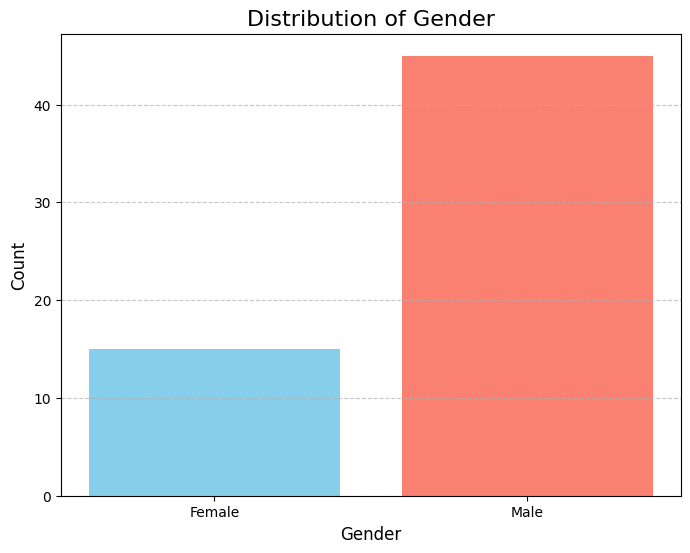

In [8]:
gender_counts = df[gender_col].value_counts().sort_index()

plt.figure(figsize=(8, 6))
plt.bar(gender_counts.index, gender_counts.values, color=['skyblue', 'salmon'])
plt.title('Distribution of Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

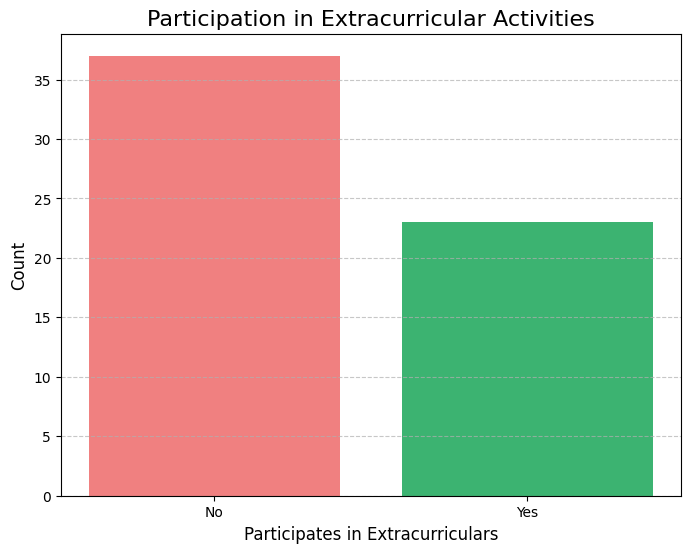

In [9]:
extracurricular_counts = df[extracurricular_col].value_counts().sort_index()

plt.figure(figsize=(8, 6))
plt.bar(extracurricular_counts.index, extracurricular_counts.values, color=['lightcoral', 'mediumseagreen'])
plt.title('Participation in Extracurricular Activities', fontsize=16)
plt.xlabel('Participates in Extracurriculars', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

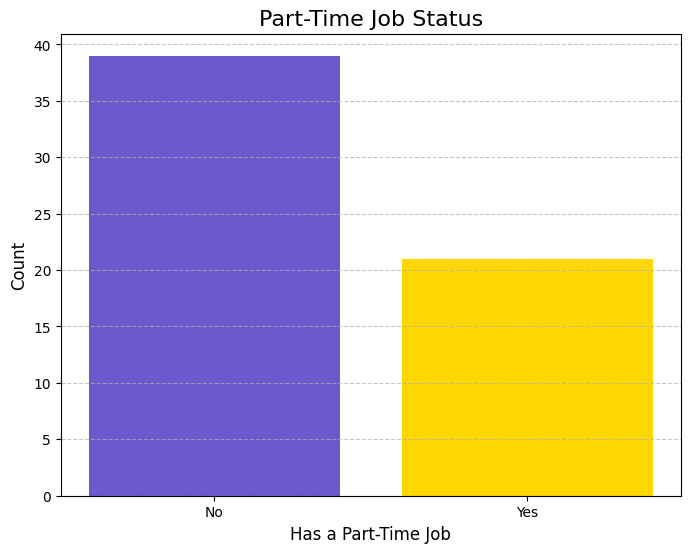

In [10]:
part_time_job_counts = df[part_time_job_col].value_counts().sort_index()

plt.figure(figsize=(8, 6))
plt.bar(part_time_job_counts.index, part_time_job_counts.values, color=['slateblue', 'gold'])
plt.title('Part-Time Job Status', fontsize=16)
plt.xlabel('Has a Part-Time Job', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
columns_to_exclude = [
    'Gender:',
    'Do you participate in extracurricular activities?  (Clubbing, Volunteering, etc.)',
    'Do you have a part-time job? '
]

df_analysis = df.drop(columns=columns_to_exclude)

stats_df = pd.DataFrame(index=[
    'Mean',
    'Median',
    'Mode',
    'Sum',
    'Variance',
    'Standard Deviation'
])

for col in df_analysis.columns:
    mean_val = df_analysis[col].mean()
    median_val = df_analysis[col].median()
    mode_val = df_analysis[col].mode()[0]
    sum_val = df_analysis[col].sum()
    var_val = df_analysis[col].var()
    std_val = df_analysis[col].std()
    
    stats_df[col] = [mean_val, median_val, mode_val, sum_val, var_val, std_val]

print("--- Statistical Analysis of Numerical Columns ---")
print(stats_df.round(2))

--- Statistical Analysis of Numerical Columns ---
                    Year of Study:     Age:  CGPA (Optional):  \
Mean                          2.33    22.23              3.57   
Median                        2.50    22.00              3.68   
Mode                          3.00    22.00              3.68   
Sum                         140.00  1334.00            214.15   
Variance                      0.77     1.50              0.22   
Standard Deviation            0.88     1.23              0.47   

                    How many hours do you spend on studying per week?  \
Mean                                                            11.58   
Median                                                          10.00   
Mode                                                            20.00   
Sum                                                            695.00   
Variance                                                        64.04   
Standard Deviation                                      

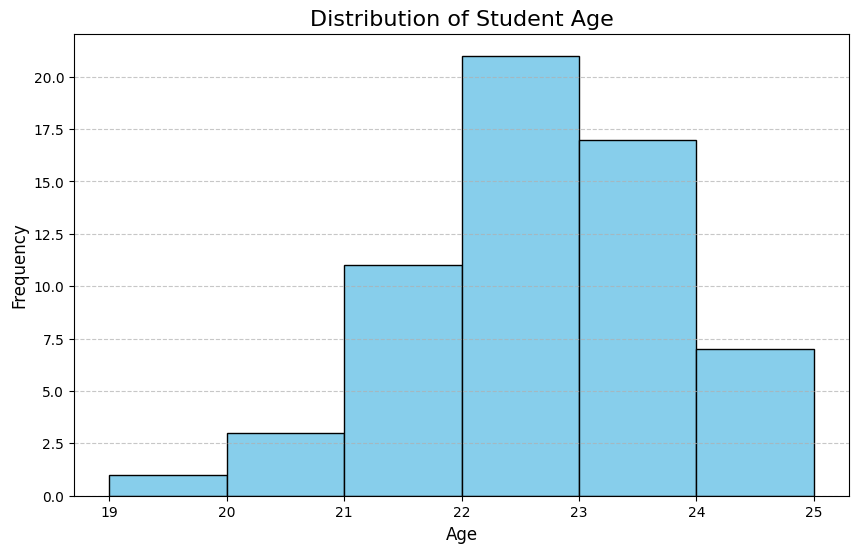

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age:'], bins='auto', color='skyblue', edgecolor='black')
plt.title('Distribution of Student Age', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

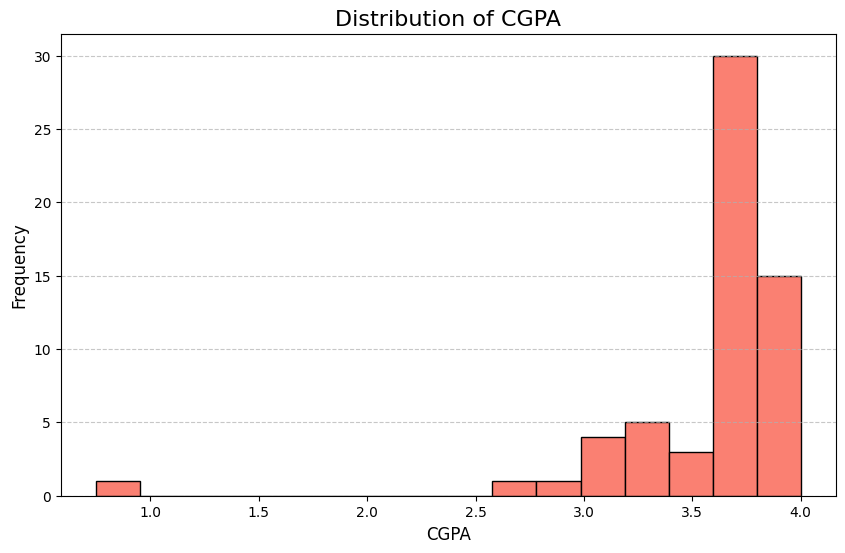

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df['CGPA (Optional):'], bins='auto', color='salmon', edgecolor='black')
plt.title('Distribution of CGPA', fontsize=16)
plt.xlabel('CGPA', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

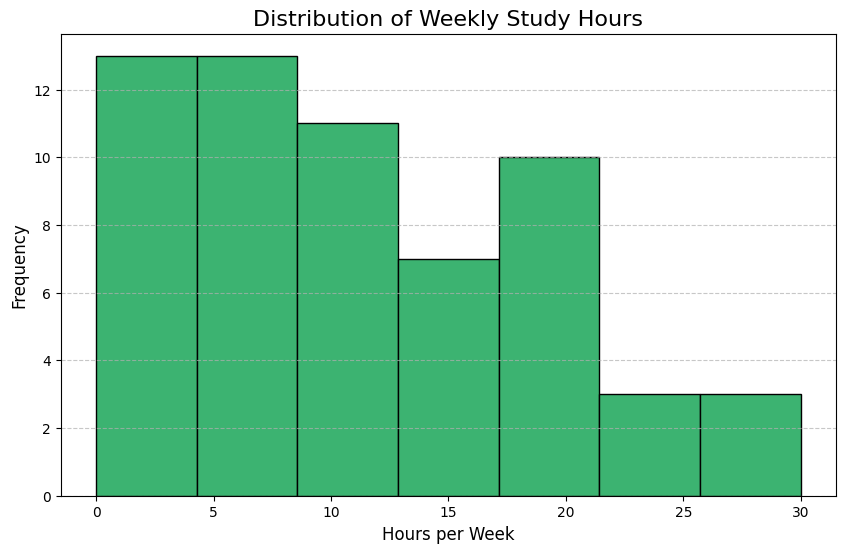

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df[study_hours_col], bins='auto', color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Weekly Study Hours', fontsize=16)
plt.xlabel('Hours per Week', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

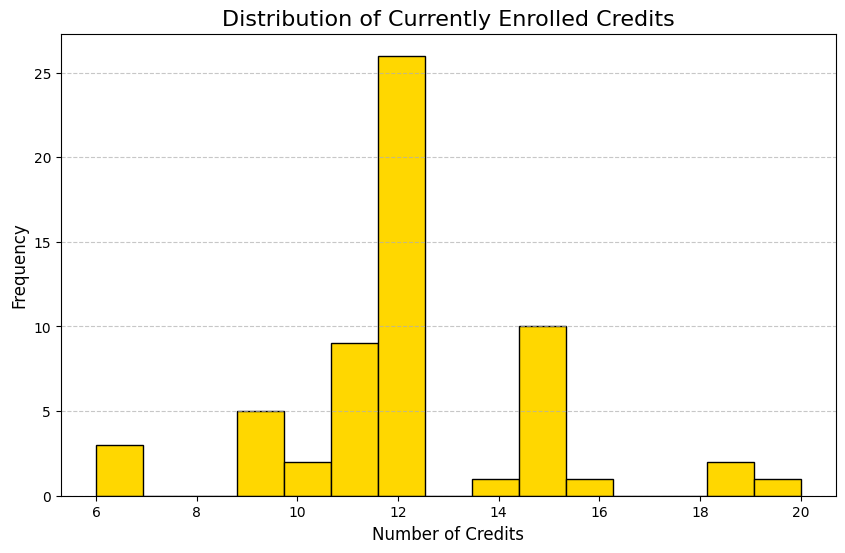

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(df[credits_col], bins='auto', color='gold', edgecolor='black')
plt.title('Distribution of Currently Enrolled Credits', fontsize=16)
plt.xlabel('Number of Credits', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

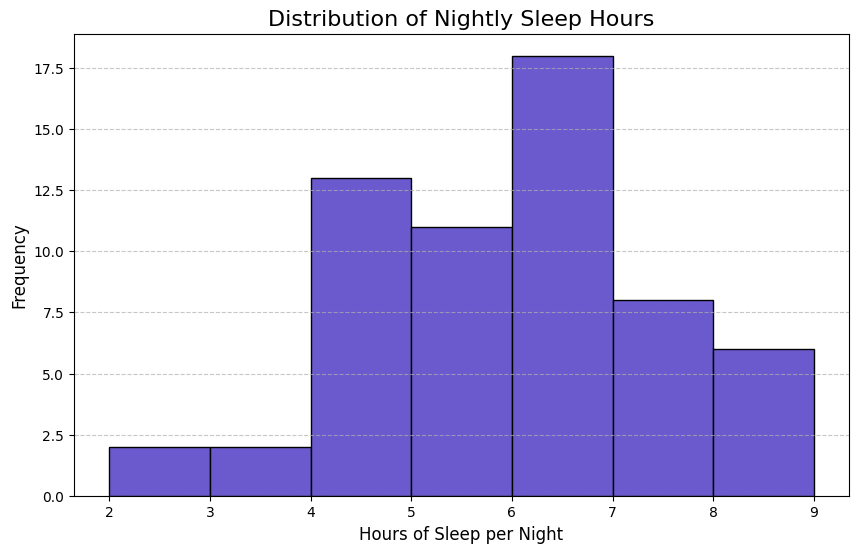

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(df[sleep_hours_col], bins='auto', color='slateblue', edgecolor='black')
plt.title('Distribution of Nightly Sleep Hours', fontsize=16)
plt.xlabel('Hours of Sleep per Night', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

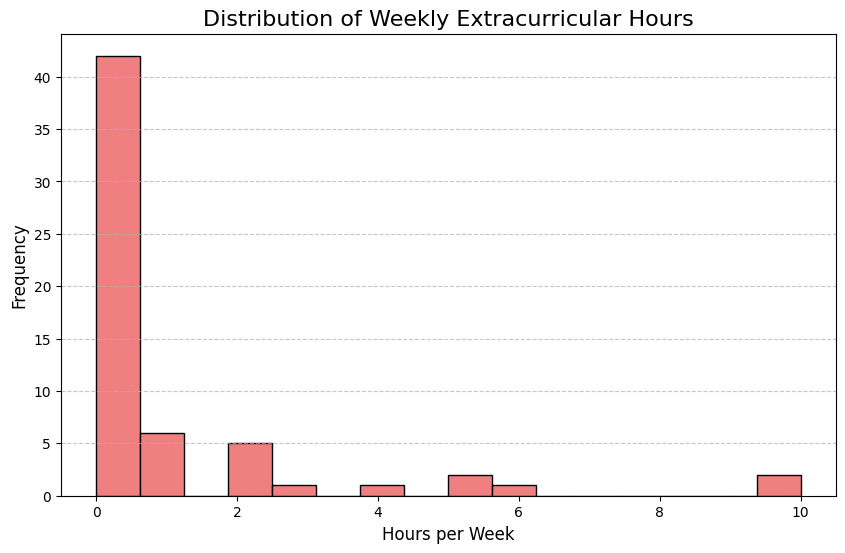

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df[extracurricular_hours_col], bins='auto', color='lightcoral', edgecolor='black')
plt.title('Distribution of Weekly Extracurricular Hours', fontsize=16)
plt.xlabel('Hours per Week', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

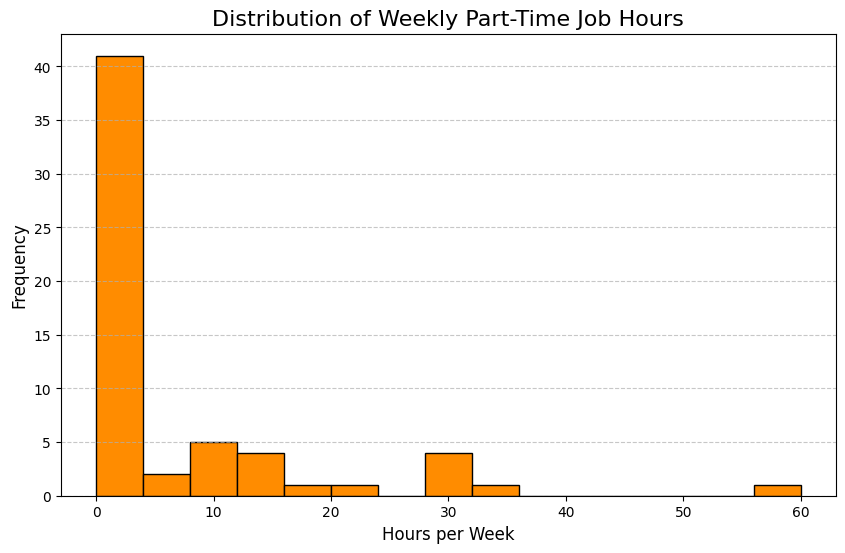

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(df[part_time_hours_col], bins='auto', color='darkorange', edgecolor='black')
plt.title('Distribution of Weekly Part-Time Job Hours', fontsize=16)
plt.xlabel('Hours per Week', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

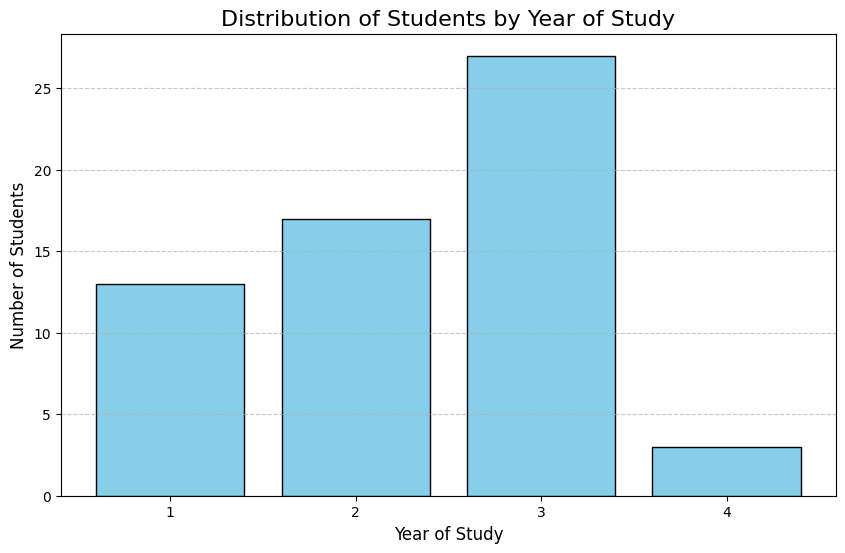

In [19]:
year_counts = df[year_col].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(year_counts.index, year_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of Students by Year of Study', fontsize=16)
plt.xlabel('Year of Study', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(year_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

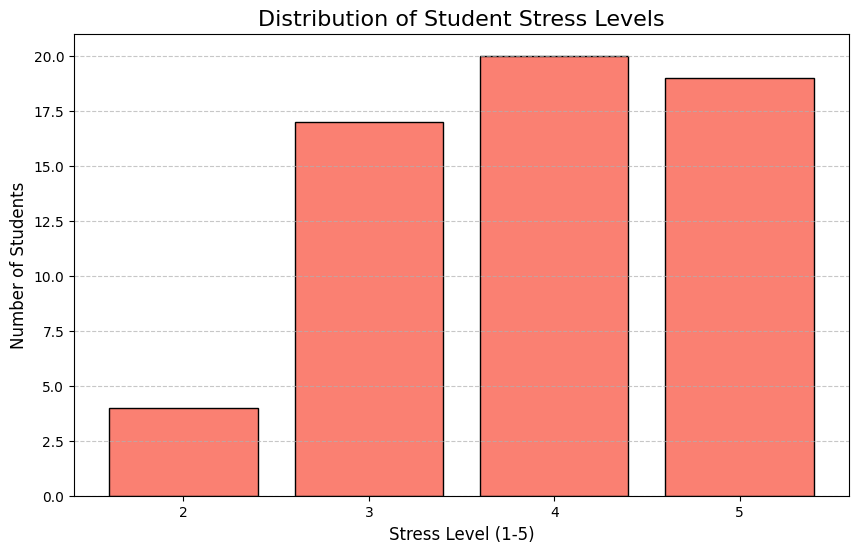

In [20]:
stress_counts = df[stress_col].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(stress_counts.index, stress_counts.values, color='salmon', edgecolor='black')
plt.title('Distribution of Student Stress Levels', fontsize=16)
plt.xlabel('Stress Level (1-5)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(stress_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

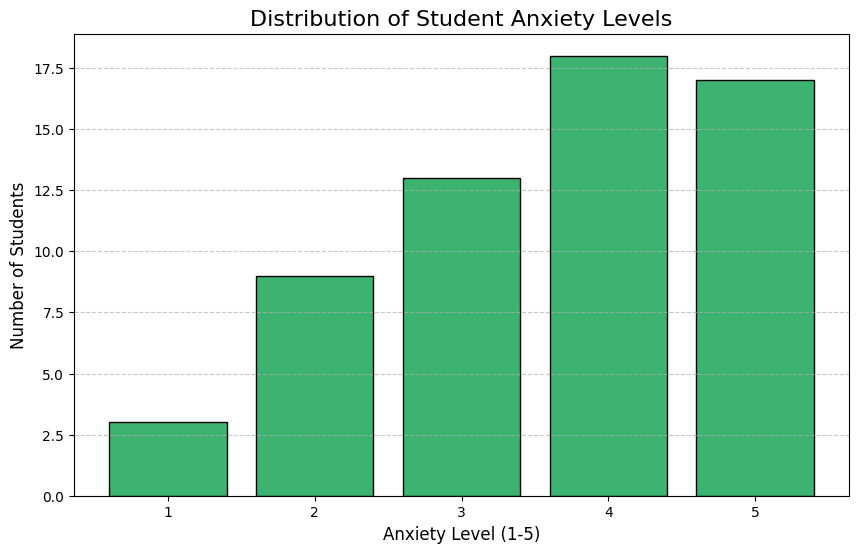

In [21]:
anxiety_counts = df[anxiety_col].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(anxiety_counts.index, anxiety_counts.values, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Student Anxiety Levels', fontsize=16)
plt.xlabel('Anxiety Level (1-5)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(anxiety_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

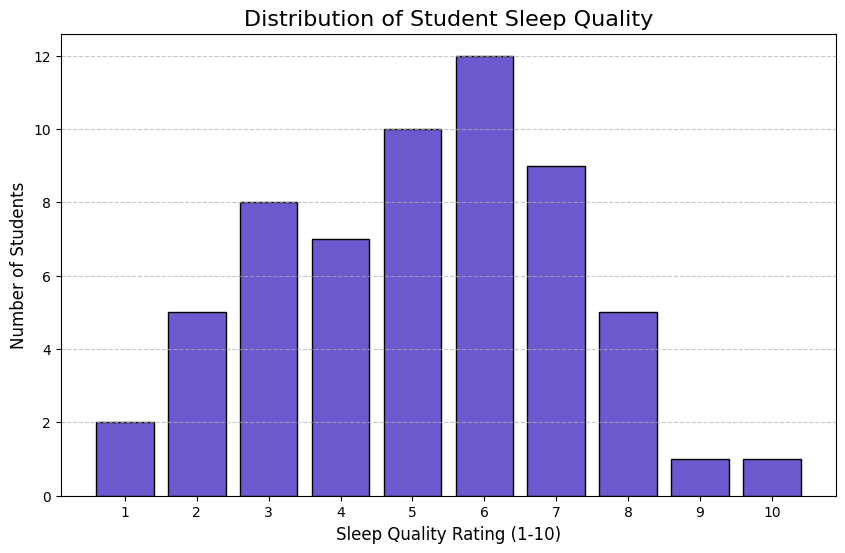

In [22]:
sleep_quality_counts = df[sleep_quality_col].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(sleep_quality_counts.index, sleep_quality_counts.values, color='slateblue', edgecolor='black')
plt.title('Distribution of Student Sleep Quality', fontsize=16)
plt.xlabel('Sleep Quality Rating (1-10)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(sleep_quality_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Correlation Analysis

In [23]:
x = df[stress_col]
y = df[anxiety_col]

mean_x = np.mean(x)
mean_y = np.mean(y)

numerator = np.sum((x - mean_x) * (y - mean_y))

denominator_x = np.sum((x - mean_x)**2)
denominator_y = np.sum((y - mean_y)**2)

denominator = np.sqrt(denominator_x * denominator_y)

correlation_coefficient = numerator / denominator

print(f"Manually Calculated Correlation Coefficient of stress level and anxiety level: {correlation_coefficient:.2f}")

# Verification using pandas' built-in function
pandas_corr = df[stress_col].corr(df[anxiety_col])
print(f"Verification using .corr(): {pandas_corr:.2f}")

Manually Calculated Correlation Coefficient of stress level and anxiety level: 0.66
Verification using .corr(): 0.66


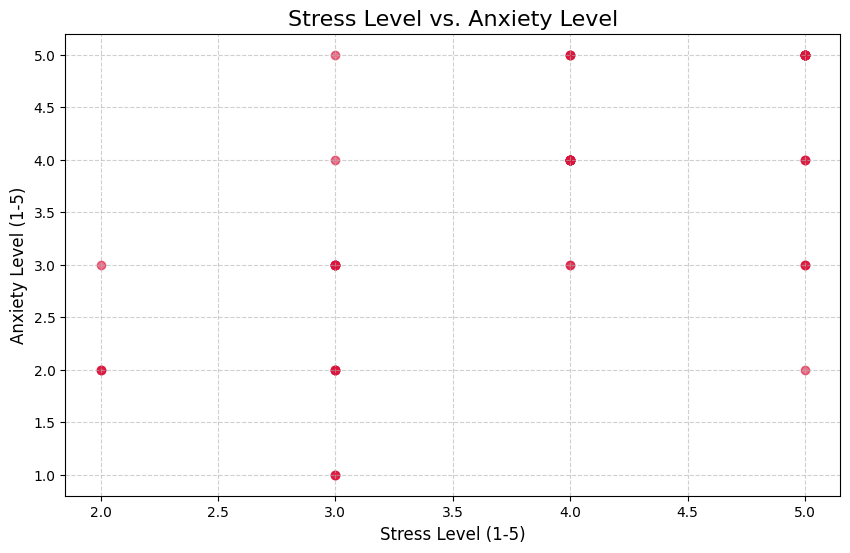

In [24]:
stress_col = 'On a scale of 1-5, how would you rate your stress level this semester?'
anxiety_col = 'On a scale of 1-5, how would you rate your anxiety level?'

x = df[stress_col]
y = df[anxiety_col]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, color='crimson')
plt.title('Stress Level vs. Anxiety Level', fontsize=16)
plt.xlabel('Stress Level (1-5)', fontsize=12)
plt.ylabel('Anxiety Level (1-5)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [25]:
x = df[sleep_hours_col]
y = df[anxiety_col]

mean_x = np.mean(x)
mean_y = np.mean(y)

numerator = np.sum((x - mean_x) * (y - mean_y))

denominator_x = np.sum((x - mean_x)**2)
denominator_y = np.sum((y - mean_y)**2)

denominator = np.sqrt(denominator_x * denominator_y)

correlation_coefficient = numerator / denominator

print(f"Manually Calculated Correlation Coefficient of sleep hours and anxiety level: {correlation_coefficient:.2f}")

# Verification using pandas' built-in function
pandas_corr = df[sleep_hours_col].corr(df[anxiety_col])
print(f"Verification using .corr(): {pandas_corr:.2f}")

Manually Calculated Correlation Coefficient of sleep hours and anxiety level: -0.35
Verification using .corr(): -0.35


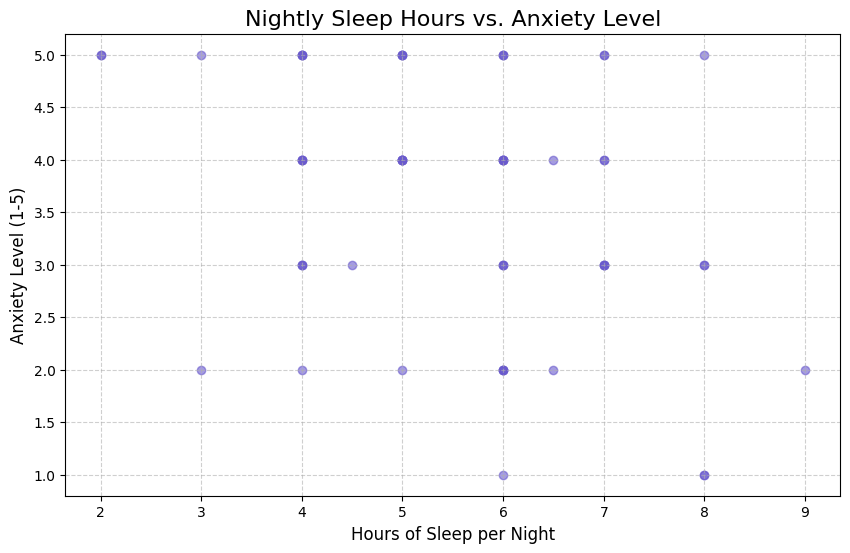

In [26]:
x = df[sleep_hours_col]
y = df[anxiety_col]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, color='slateblue')
plt.title('Nightly Sleep Hours vs. Anxiety Level', fontsize=16)
plt.xlabel('Hours of Sleep per Night', fontsize=12)
plt.ylabel('Anxiety Level (1-5)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Box Plot Analysis

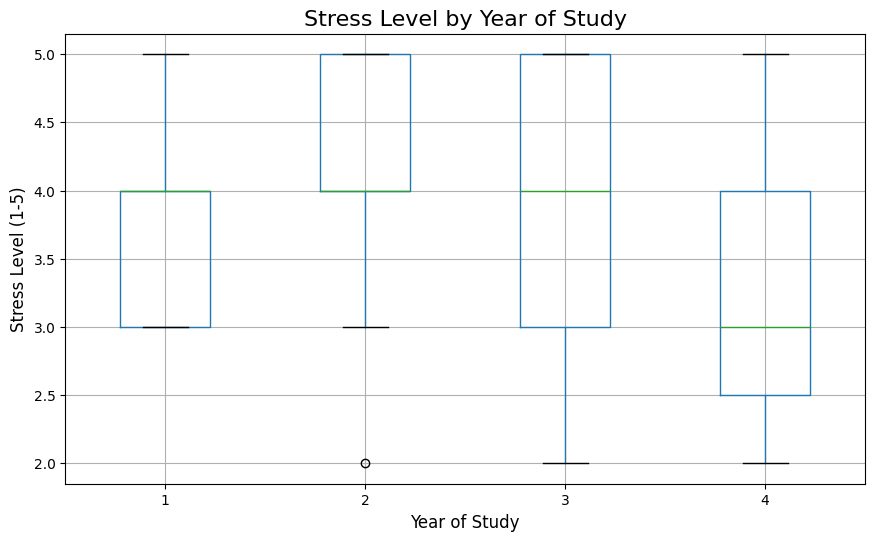

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column=stress_col, by=year_col, ax=ax, grid=True)

fig.suptitle('') 
plt.title('Stress Level by Year of Study', fontsize=16)
plt.xlabel('Year of Study', fontsize=12)
plt.ylabel('Stress Level (1-5)', fontsize=12)

plt.show()

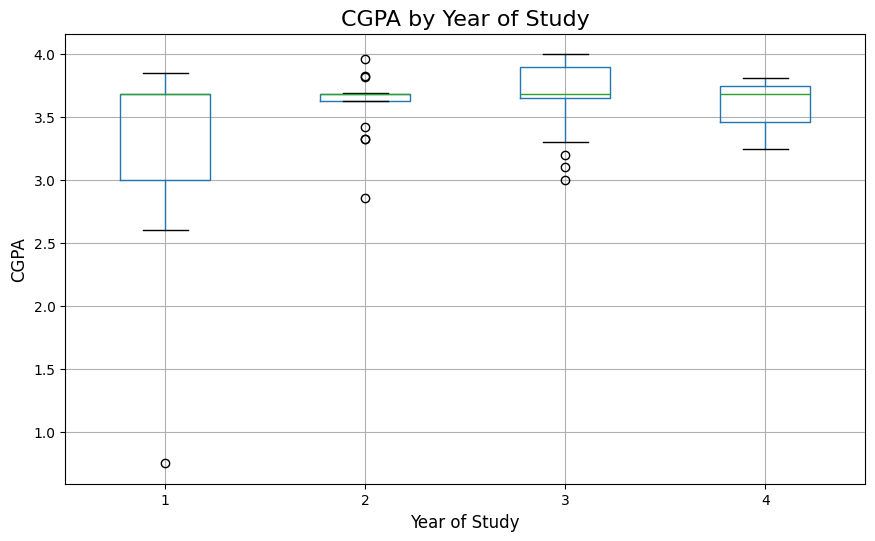

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column=cgpa_col, by=year_col, ax=ax, grid=True)

fig.suptitle('')
plt.title('CGPA by Year of Study', fontsize=16)
plt.xlabel('Year of Study', fontsize=12)
plt.ylabel('CGPA', fontsize=12)

plt.show()

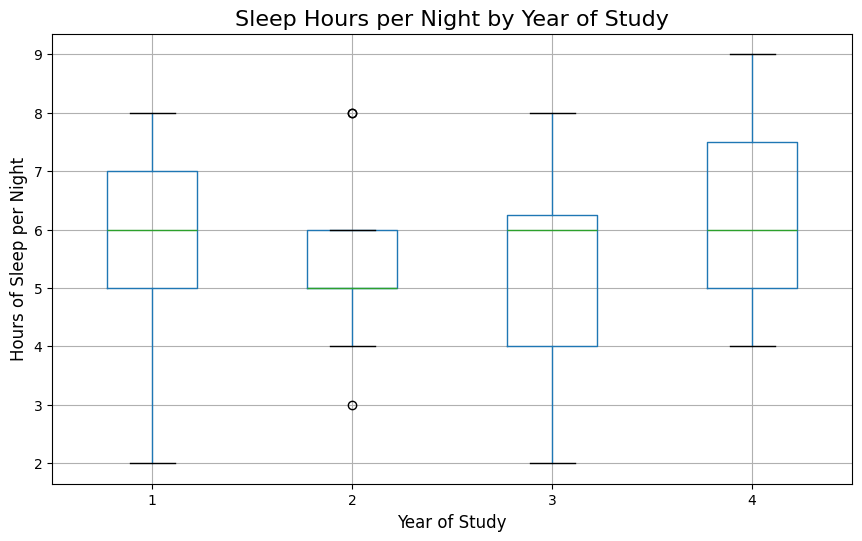

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column=sleep_hours_col, by=year_col, ax=ax, grid=True)

fig.suptitle('')
plt.title('Sleep Hours per Night by Year of Study', fontsize=16)
plt.xlabel('Year of Study', fontsize=12)
plt.ylabel('Hours of Sleep per Night', fontsize=12)

plt.show()

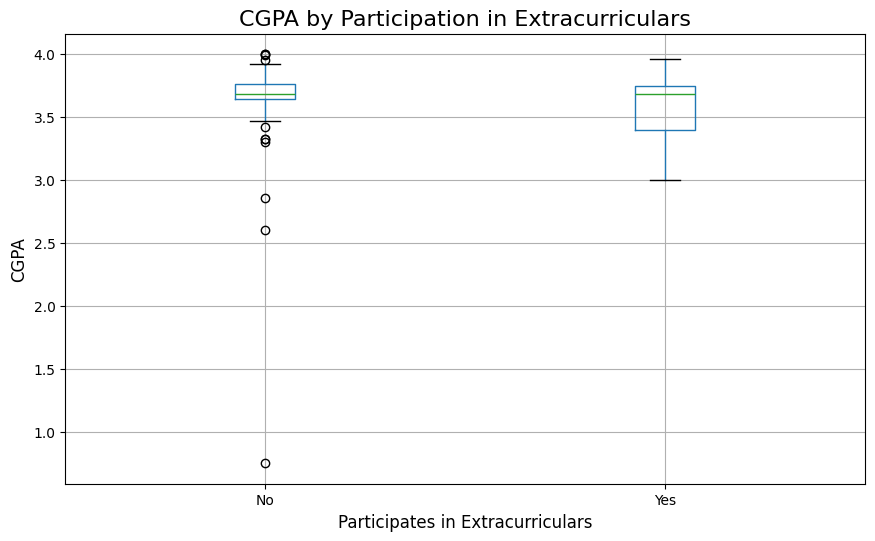

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column=cgpa_col, by=extracurricular_col, ax=ax, grid=True)

fig.suptitle('')
plt.title('CGPA by Participation in Extracurriculars', fontsize=16)
plt.xlabel('Participates in Extracurriculars', fontsize=12)
plt.ylabel('CGPA', fontsize=12)
ax.set_xticklabels(['No', 'Yes'])

plt.show()

In [32]:
x = df['If yes, how many hours per week? \n(Leave it blank if you do not participate)']
y = df['On a scale of 1-5, how would you rate your stress level this semester?']

In [33]:
x1 = df['If yes, how many hours per week do you spend on extracurricular activities?  (Leave it blank if you do not participate)']
y1 = df['On average, how many hours of sleep do you get per night?']

In [35]:
x2 = df['If yes, how many hours per week? \n(Leave it blank if you do not participate)']
y2 = df['On a scale of 1-10, how would you rate your overall sleep quality?']

# Manual Implementation of Linear Regression (OLS)

In [40]:
def ols_linear_regression(x: pd.Series,y: pd.Series):
  x=x.fillna(0)
  y = y.fillna(0)
  x_mean = np.mean(x)
  y_mean = np.mean(y)
  numerator = np.sum((x - x_mean) * (y - y_mean))
  denominator = np.sum((x - x_mean) ** 2)
  if denominator == 0:
    return np.nan, np.nan
  w = numerator/denominator
  b = y_mean - w * x_mean
  return w, b

In [41]:
#using ols function

#Part time job hours vs Stress level
w,b = ols_linear_regression(pd.Series(x),pd.Series(y))
print(f"w: {w}, b: {b} ")
#Extracurricular hours vs Sleep hours
w1,b1 = ols_linear_regression(pd.Series(x1),pd.Series(y1))
print(f"w: {w1}, b: {b1} ")
# Part-time job hours vs sleep quality
w2,b2 = ols_linear_regression(pd.Series(x2),pd.Series(y2))
print(f"w: {w2}, b: {b2} ")

w: 0.013437643054651753, b: 3.819150180954512 
w: 0.09328514248162972, b: 5.433269609893064 
w: -0.02341836724220397, b: 5.274233842907261 


# Scatter Plot Analysis

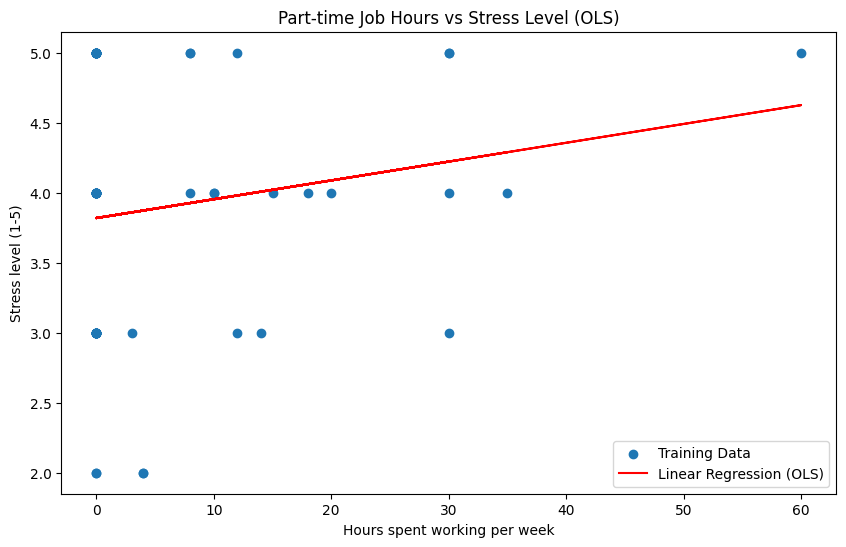

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Training Data')
plt.plot(x, np.dot(x, w) + b, color='red', label='Linear Regression (OLS)')
plt.xlabel('Hours spent working per week')
plt.ylabel('Stress level (1-5)')
plt.title('Part-time Job Hours vs Stress Level (OLS)')
plt.legend()
plt.show()

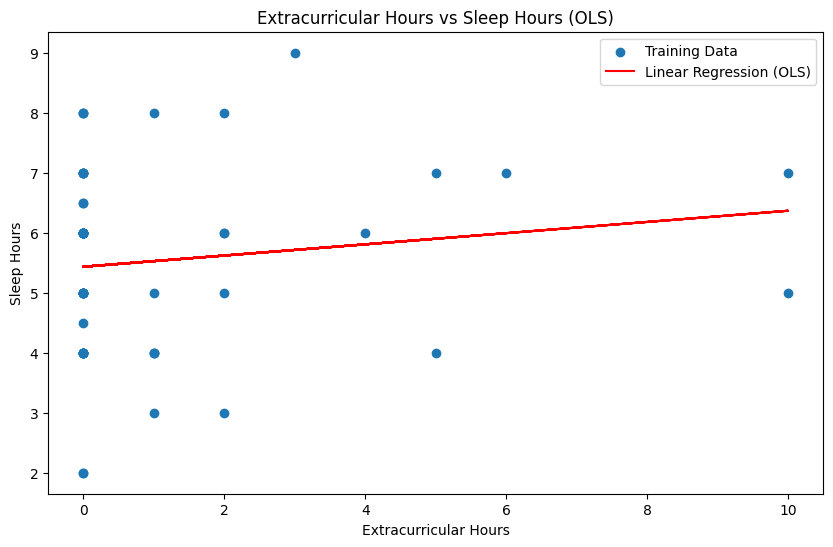

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(x1, y1, label='Training Data')
plt.plot(x1, np.dot(x1, w1) + b1, color='red', label='Linear Regression (OLS)')
plt.xlabel('Extracurricular Hours')
plt.ylabel('Sleep Hours')
plt.title('Extracurricular Hours vs Sleep Hours (OLS)')
plt.legend()
plt.show()

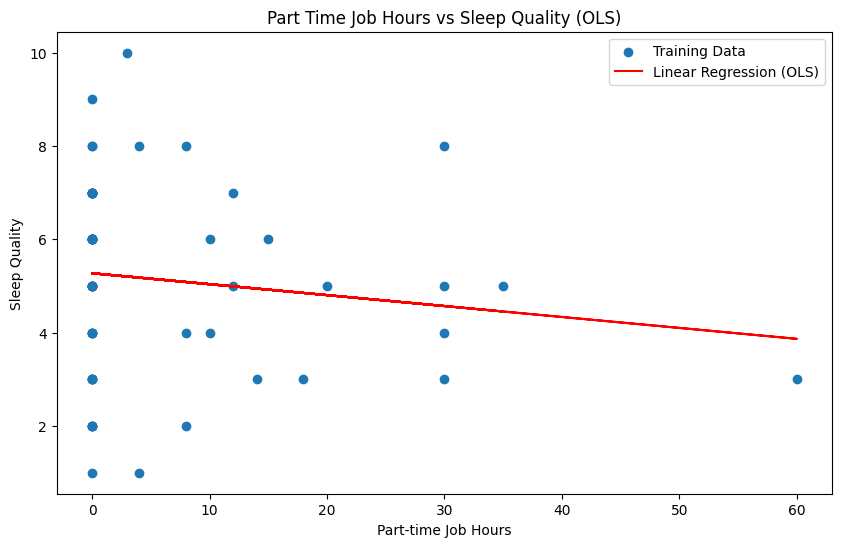

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(x2, y2, label='Training Data')
plt.plot(x2, np.dot(x2, w2) + b2, color='red', label='Linear Regression (OLS)')
plt.xlabel('Part-time Job Hours')
plt.ylabel('Sleep Quality')
plt.title('Part Time Job Hours vs Sleep Quality (OLS)')
plt.legend()
plt.show()

In [45]:
def calculate_r_squared(x, y, w, b):
    """
    Calculates the R-squared value for a simple linear regression model.
    x: Independent variable (pandas Series)
    y: Dependent variable (pandas Series)
    w: Slope of the regression line
    b: Intercept of the regression line
    """
    y_predicted = w * x + b
    mean_y = np.mean(y)
    
    # Calculate Total Sum of Squares (SS_total)
    ss_total = np.sum((y - mean_y)**2)
    
    # Calculate Residual Sum of Squares (SS_residual)
    ss_residual = np.sum((y - y_predicted)**2)
    
    # Calculate R-squared
    r_squared = 1 - (ss_residual / ss_total)
    return r_squared

# Regression Model 1: Part-Time Job Hours vs Stress Level

In [46]:
# --- OLS Model 1: Part-time job hours vs Stress level ---
w1, b1 = 0.013437643054651753, 3.819150180954512
r_squared_ols_1 = calculate_r_squared(df[part_time_hours_col], df[stress_col], w1, b1)

# --- OLS Model 2: Extracurricular hours vs Sleep hours ---
w2, b2 = 0.09328514248162972, 5.433269609893064
r_squared_ols_2 = calculate_r_squared(df[extracurricular_hours_col], df[sleep_hours_col], w2, b2)

# --- OLS Model 3: Part-time job hours vs Sleep quality ---
w3, b3 = -0.02341836724220397, 5.274233842907261
r_squared_ols_3 = calculate_r_squared(df[part_time_hours_col], df[sleep_quality_col], w3, b3)


# --- Print the results for the OLS models ---
print("--- R-squared Values for OLS Models ---")
print(f"OLS Model 1 (Part-time job hours vs Stress level): {r_squared_ols_1:.4f}")
print(f"OLS Model 2 (Extracurricular hours vs Sleep hours): {r_squared_ols_2:.4f}")
print(f"OLS Model 3 (Part-time job hours vs Sleep quality): {r_squared_ols_3:.4f}")

--- R-squared Values for OLS Models ---
OLS Model 1 (Part-time job hours vs Stress level): 0.0285
OLS Model 2 (Extracurricular hours vs Sleep hours): 0.0180
OLS Model 3 (Part-time job hours vs Sleep quality): 0.0179


In [48]:
def calculate_errors(x, y, w, b):
    """
    Calculates MAE, MSE, and RMSE for a simple linear regression model.
    """
    y_predicted = w * x + b
    errors = y - y_predicted
    
    mae = np.mean(np.abs(errors))
    mse = np.mean(errors**2)
    rmse = np.sqrt(mse)
    
    return mae, mse, rmse


In [49]:
# --- OLS Model 1: Part-time job hours vs Stress level ---
w1, b1 = 0.013437643054651753, 3.819150180954512
mae1, mse1, rmse1 = calculate_errors(df[part_time_hours_col], df[stress_col], w1, b1)

# --- OLS Model 2: Extracurricular hours vs Sleep hours ---
w2, b2 = 0.09328514248162972, 5.433269609893064
mae2, mse2, rmse2 = calculate_errors(df[extracurricular_hours_col], df[sleep_hours_col], w2, b2)

# --- OLS Model 3: Part-time job hours vs Sleep quality ---
w3, b3 = -0.02341836724220397, 5.274233842907261
mae3, mse3, rmse3 = calculate_errors(df[part_time_hours_col], df[sleep_quality_col], w3, b3)


# --- Print the results for the OLS models ---
print("--- Error Metrics for OLS Models ---")
print("\nModel 1 (Part-time job hours vs Stress level):")
print(f"  MAE: {mae1:.4f}")
print(f"  MSE: {mse1:.4f}")
print(f"  RMSE: {rmse1:.4f}")

print("\nModel 2 (Extracurricular hours vs Sleep hours):")
print(f"  MAE: {mae2:.4f}")
print(f"  MSE: {mse2:.4f}")
print(f"  RMSE: {rmse2:.4f}")

print("\nModel 3 (Part-time job hours vs Sleep quality):")
print(f"  MAE: {mae3:.4f}")
print(f"  MSE: {mse3:.4f}")
print(f"  RMSE: {rmse3:.4f}")

--- Error Metrics for OLS Models ---

Model 1 (Part-time job hours vs Stress level):
  MAE: 0.7595
  MSE: 0.8322
  RMSE: 0.9123

Model 2 (Extracurricular hours vs Sleep hours):
  MAE: 1.2290
  MSE: 2.2131
  RMSE: 1.4876

Model 3 (Part-time job hours vs Sleep quality):
  MAE: 1.6472
  MSE: 4.0747
  RMSE: 2.0186
